In [2]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [3]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from eICUUtil import *

/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [4]:
def getCovariatePreprocessor(aKeepColumns):
    return ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

In [5]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=10)
    myImputer.set_output(transform="pandas")
    myCovariates = getCovariatePreprocessor(['bin__' + 'treatment_hypothermia'])
    myImputer.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor), ('imputer', myImputer), ('covariates', myCovariates)]

In [6]:
myPredictorsDf, X_train, X_test, y_train, y_test = \
            getTrainTestFunctions(aPredictedColumn = 'DeathAtDischarge', 
                                     aTreatmentColumn = 'treatment_hypothermia', 
                                     aDropColumns = ['Hypothermia', 'both_hypothermia', 'treatment_therapy for controlling cerebral perfusion pressure', 
                                                     'treatment_neurologic', 'treatment_neuromuscular blocking agent', 'treatment_subcutaneous']) 

/home/idies/workspace/Storage/hkim171/ACCM_PMAP_SEPSIS/mbranda1/ttmhte/eICU/eICUUtil.py:6: DtypeWarning: Columns (2059,2070,2081,2083,2084,2089,2095,2099,2108,2119,2130,2132,2133,2138,2144,2148,2305,2307) have mixed types. Specify dtype option on import or set low_memory=False.
  myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')


In [7]:
# def getDefaultPipelineSteps(X_train):
#     myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
#     myBinaryColumns = X_train.columns[X_train.nunique() == 2]
#     myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
#     return [('preprocessor', myPreprocessor), ('imputer', KNNImputer(n_neighbors=10)), \
#             ('sfs', SFS(estimator = XGBClassifier(max_depth = 10, n_estimators = 100, n_jobs=-1), 
#                         verbose =2, n_jobs=-1, k_features=50, forward=True, floating=True, cv=5))]

In [8]:
DefaultGrid = [
    {
        'clf': [XGBClassifier(eval_metric='logloss'), RandomForestClassifier()],
        'clf__n_estimators': [25, 100, 500], 
        'clf__max_depth': [10, 50, 100]
    },
    # {
    #     'clf': [XGBClassifier(eval_metric='logloss')],
    #     'clf__n_estimators': [50], 
    #     'clf__max_depth': [10]
    # }
    # {
    #     'clf': [DecisionTreeClassifier()],
    #     'clf__max_depth': [2, 5, 20, 50, None],
    #     'clf__class_weight': [None, 'balanced']
    # },
    {
        'clf': [LogisticRegression(), SVC(probability=True)],
        'clf__C': [0.01, 0.1, 1, 10, 100]
    }
    # {
    #     'clf': [KerasClassifier(model=build_model, epochs=30, batch_size=32, verbose=1)]
    # }
]
def gridSearchKFoldClassification(X_train, X_test, y_train, y_test, aScore = 'roc_auc', aGrid = DefaultGrid):
    kf = StratifiedKFold(n_splits=5, shuffle=True)
    myPipelineSteps = getDefaultPipelineSteps(X_train = X_train)
    myPipelineSteps.append(('clf', XGBClassifier()))
    myPipeline = Pipeline(myPipelineSteps)
    myGridSearchCv = GridSearchCV(myPipeline, aGrid, cv=kf, scoring=aScore, n_jobs=-1, verbose=3)
    myGridSearchCv.fit(X_train, y_train)
    myBestModel = myGridSearchCv.best_estimator_
    y_pred_proba = myBestModel.predict_proba(X_test)[:, 1]
    y_pred = myBestModel.predict(X_test)
    print(f'Best parameters: {myGridSearchCv.best_params_}')
    print(f'Best cross val {aScore} score: {myGridSearchCv.best_score_:.4f}')
    print(f'Area under the receiver operating curve on test set is {roc_auc_score(y_test, y_pred_proba):.4f}')
    print(f'Accuracy score on test set is {accuracy_score(y_test, y_pred):.4f}')
    return myGridSearchCv
myGridSearchCv = gridSearchKFoldClassification(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='roc_auc', aGrid = DefaultGrid)
myBestModel = myGridSearchCv.best_estimator_

Fitting 5 folds for each of 28 candidates, totalling 140 fits


/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain f

[CV 4/5] END clf=XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...), clf__max_depth=50, clf__n_estimators=25;, score=0.710 total time=  55.7s
[CV 4/5] END clf=XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
       

/home/idies/miniconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/idies/miniconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regr

[CV 3/5] END clf=LogisticRegression(), clf__C=1;, score=0.739 total time=  49.3s
[CV 4/5] END clf=LogisticRegression(), clf__C=1;, score=0.723 total time=  49.4s
[CV 2/5] END clf=LogisticRegression(), clf__C=1;, score=0.757 total time=  55.7s


...

[CV 5/5] END clf=LogisticRegression(), clf__C=1;, score=0.709 total time=  49.4s


/home/idies/miniconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/idies/miniconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regr

[CV 5/5] END clf=LogisticRegression(), clf__C=10;, score=0.700 total time=  46.3s
[CV 4/5] END clf=LogisticRegression(), clf__C=10;, score=0.712 total time=  47.6s
[CV 3/5] END clf=LogisticRegression(), clf__C=10;, score=0.731 total time=  49.0s


/home/idies/miniconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/idies/miniconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regr

[CV 5/5] END clf=LogisticRegression(), clf__C=100;, score=0.698 total time=  44.1s
[CV 4/5] END clf=LogisticRegression(), clf__C=100;, score=0.711 total time=  47.9s
[CV 2/5] END clf=LogisticRegression(), clf__C=10;, score=0.753 total time=  56.4s
[CV 1/5] END clf=LogisticRegression(), clf__C=10;, score=0.728 total time=  59.3s
[CV 3/5] END clf=LogisticRegression(), clf__C=100;, score=0.730 total time=  53.3s
[CV 3/5] END clf=SVC(probability=True), clf__C=0.01;, score=0.768 total time=  49.9s
[CV 1/5] END clf=LogisticRegression(), clf__C=100;, score=0.727 total time= 1.0min
[CV 5/5] END clf=SVC(probability=True), clf__C=0.01;, score=0.765 total time=  51.0s
[CV 2/5] END clf=LogisticRegression(), clf__C=100;, score=0.753 total time= 1.1min
[CV 4/5] END clf=SVC(probability=True), clf__C=0.01;, score=0.747 total time=  57.5s
[CV 2/5] END clf=SVC(probability=True), clf__C=0.01;, score=0.735 total time= 1.1min
[CV 1/5] END clf=SVC(probability=True), clf__C=0.01;, score=0.722 total time= 1.2

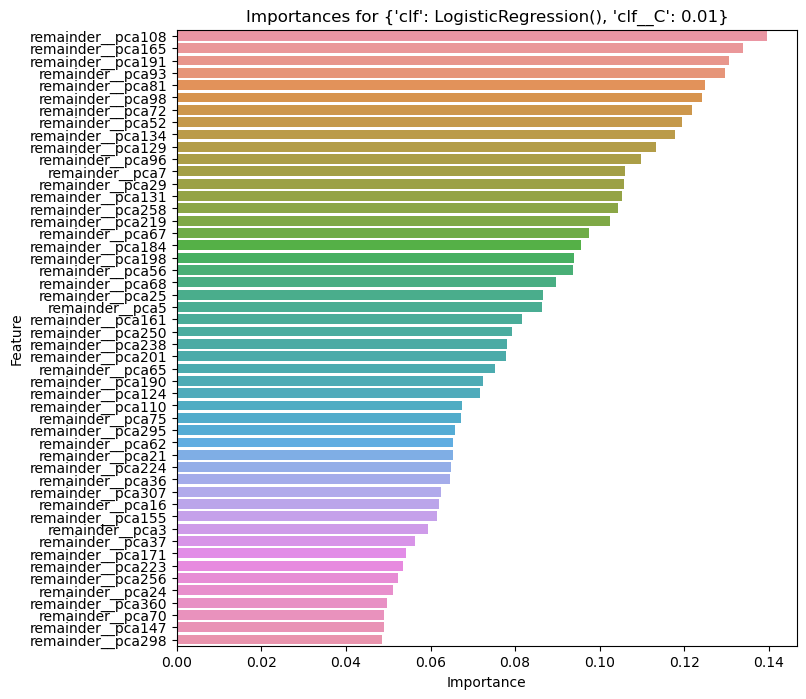

In [9]:
myFeatureImportancesDf = getTopFeatures(myGridSearchCv, list(myBestModel.named_steps.covariates.get_feature_names_out()), X_train, y_train)

In [10]:
myFeatureImportancesDf[myFeatureImportancesDf.Feature == 'keep__bin__treatment_hypothermia']

,Feature,Importance
0,keep__bin__treatment_hypothermia,0.017515


Optimization terminated successfully.
         Current function value: 0.684998
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.684607
         Iterations 4
Likelihood ratio of test results:
Chi square statistic: 1.448551293426135
p-value: 0.22876055203554263
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       DeathAtDischarge   No. Observations:                 1852
Model:                          Logit   Df Residuals:                     1849
Method:                           MLE   Df Model:                            2
Date:                Sat, 15 Mar 2025   Pseudo R-squ.:                0.002485
Time:                        15:13:40   Log-Likelihood:                -1268.6
converged:                       True   LL-Null:                       -1271.8
Covariance Type:            nonrobust   LLR p-value:                   0.04243
                      

0.22876055203554263

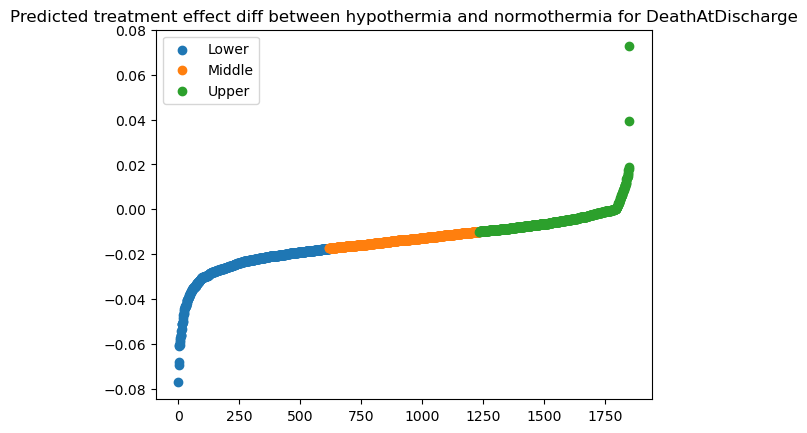

In [11]:
getTreatmentEffectDiff(aX = X_train, aY = y_train.reset_index().drop(columns='index'), aModel = myBestModel, \
                       aCategory = 'DeathAtDischarge', aGroup = 'gender', aUseNeuralNetwork = False, aByGroup =False)

In [25]:
getTreatmentEffectDiff(aX = X_train, aY = y_train.reset_index().drop(columns='index'), aModel = myBestModel, \
                       aCategory = 'LastMGCSPositive', aGroup = 'treatment_hypothermia', aUseNeuralNetwork = False, aByGroup =False)

No effect difference


TypeError: object of type 'int' has no len()

In [28]:
SFS(estimator = XGBClassifier(max_depth = 50, n_estimators = 200))

SequentialFeatureSelector(estimator=XGBClassifier(base_score=None, booster=None,
                                                  callbacks=None,
                                                  colsample_bylevel=None,
                                                  colsample_bynode=None,
                                                  colsample_bytree=None,
                                                  device=None,
                                                  early_stopping_rounds=None,
                                                  enable_categorical=False,
                                                  eval_metric=None,
                                                  feature_types=None,
                                                  gamma=None, grow_policy=None,
                                                  importance_type=None,
                                                  interaction_constraints=None,
                                                  learning_rate=None,
                                                  max_bin=None,
                                                  max_cat_threshold=None,
                                                  max_cat_to_onehot=None,
                                                  max_delta_step=None,
                                                  max_depth=50, max_leaves=None,
                                                  min_child_weight=None,
                                                  missing=nan,
                                                  monotone_constraints=None,
                                                  multi_strategy=None,
                                                  n_estimators=200, n_jobs=None,
                                                  num_parallel_tree=None,
                                                  random_state=None, ...),
                          scoring='accuracy')

In [75]:
myPredictorsDf[myPredictorsDf['treatment_hypothermia'] == 1][['treatment_hypothermia', 'Hypothermia']].sum()

treatment_hypothermia    447.0
Hypothermia              259.0
dtype: float64